**Project:** Large-Scale E-Commerce Product Classification
**Objective:** Developed a deep learning pipeline to categorize over 100,000 diverse product images into 42 distinct categories for the Shopee marketplace.

**Methodology:** Leveraged Transfer Learning with a MobileNetV2 architecture, followed by strategic Fine-Tuning and Class Weighting to address significant dataset imbalances.

**Outcome:** Achieved a final validation accuracy of 72.4%, successfully transitioning from a frozen baseline to a specialized model capable of distinguishing fine-grained product features.

In [3]:
import tensorflow as tf
import pandas as pd
import os
import numpy as np
import matplotlib.pyplot as plt

In [4]:
print(tf.config.list_physical_devices('GPU'))

[PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [5]:
import kagglehub

# This will download the dataset directly to the Colab VM
path = kagglehub.dataset_download("kennethrithvik/shopee")
print("Path to dataset files:", path)

100%|██████████| 9.38G/9.38G [01:46<00:00, 94.4MB/s]

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/kennethrithvik/shopee/versions/3


In [10]:
print(os.listdir(path))
train_df = pd.read_csv(os.path.join(path, 'train.csv'))
display(df.head())

['test', 'test.csv', 'train', 'train.csv']


,filename,category
0,45e2d0c97f7bdf8cbf3594beb6fdcda0.jpg,3
1,f74d1a5fc2498bbbfa045c74e3cc333e.jpg,3
2,f6c172096818c5fab10ecae722840798.jpg,3
3,251ffd610399ac00fea7709c642676ee.jpg,3
4,73c7328b8eda399199fdedec6e4badaf.jpg,3


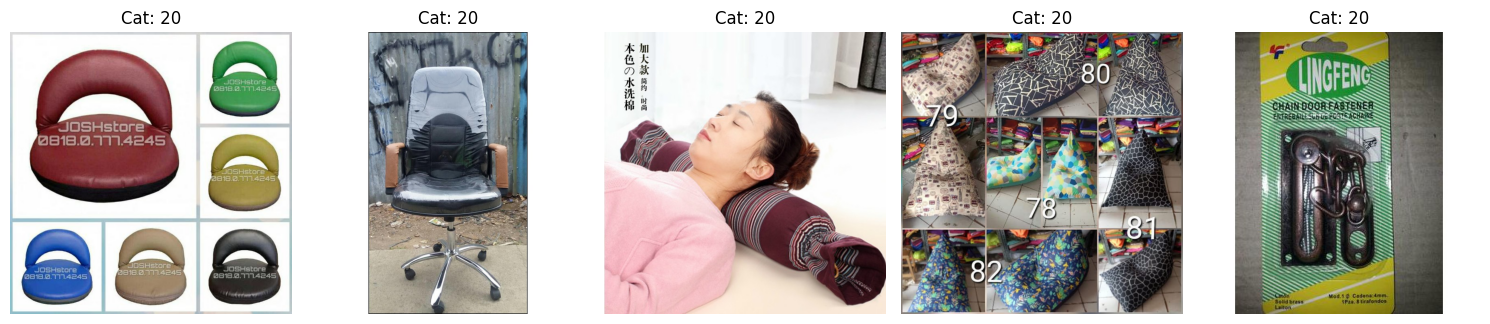

In [14]:
from PIL import Image

image_dir = r"/root/.cache/kagglehub/datasets/kennethrithvik/shopee/versions/3/train/train"

def display_batch(df, img_dir, category_id, n=5):
    sample = df[df['category'] == category_id].sample(n)

    plt.figure(figsize=(15, 5))
    for i, (idx, row) in enumerate(sample.iterrows()):
        img_path = os.path.join(img_dir, str(category_id), row['filename'])

        try:
            img = Image.open(img_path)
            plt.subplot(1, n, i+1)
            plt.imshow(img)
            plt.title(f"Cat: {category_id}")
            plt.axis('off')
        except Exception as e:
            print(f"Error loading {row['filename']}: {e}")
    plt.tight_layout()
    plt.show()

display_batch(train_df, image_dir, category_id=20)

In [15]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

datagen = ImageDataGenerator(
    rescale=1./255,          # Normalization (0-255 to 0-1)
    validation_split=0.2     # Automatically sets aside 20% for testing
)

train_generator = datagen.flow_from_directory(
    image_dir,
    target_size=(224, 224),
    batch_size=32,
    class_mode='categorical',
    subset='training'
)

val_generator = datagen.flow_from_directory(
    image_dir,
    target_size=(224, 224),
    batch_size=32,
    class_mode='categorical',
    subset='validation'
)

Found 84331 images belonging to 42 classes.
Found 21061 images belonging to 42 classes.


In [37]:
from tensorflow.keras import layers, models, Input

# 1. Use the pre-trained 'Body' (MobileNetV2)
base_model = tf.keras.applications.MobileNetV2(
    input_shape=(224, 224, 3),
    include_top=False,
    weights='imagenet'
)
base_model.trainable = False

# 2. Build the Model
model = models.Sequential([
    Input(shape=(224, 224, 3)),
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.2),             # Prevents overfitting
    layers.Dense(42, activation='softmax')
])

model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 42)             │         5,418 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,427,370 (9.26 MB)

 Trainable params: 169,386 (661.66 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [19]:
from tensorflow.keras.callbacks import EarlyStopping

early_stop = EarlyStopping(monitor='val_loss', patience=2, restore_best_weights=True)

history = model.fit(
    train_generator,
    epochs=10,
    validation_data=val_generator,
    callbacks=[early_stop]
)

Epoch 1/10
2636/2636 ━━━━━━━━━━━━━━━━━━━━ 568s 208ms/step - accuracy: 0.5764 - loss: 1.5673 - val_accuracy: 0.6425 - val_loss: 1.2985
Epoch 2/10
2636/2636 ━━━━━━━━━━━━━━━━━━━━ 488s 185ms/step - accuracy: 0.6424 - loss: 1.2974 - val_accuracy: 0.6521 - val_loss: 1.2662
Epoch 3/10
2636/2636 ━━━━━━━━━━━━━━━━━━━━ 480s 182ms/step - accuracy: 0.6639 - loss: 1.2111 - val_accuracy: 0.6612 - val_loss: 1.2464
Epoch 4/10
2636/2636 ━━━━━━━━━━━━━━━━━━━━ 481s 183ms/step - accuracy: 0.6784 - loss: 1.1457 - val_accuracy: 0.6675 - val_loss: 1.2213
Epoch 5/10
2636/2636 ━━━━━━━━━━━━━━━━━━━━ 483s 183ms/step - accuracy: 0.6884 - loss: 1.1018 - val_accuracy: 0.6732 - val_loss: 1.2293
Epoch 6/10
2636/2636 ━━━━━━━━━━━━━━━━━━━━ 523s 199ms/step - accuracy: 0.6985 - loss: 1.0549 - val_accuracy: 0.6687 - val_loss: 1.2284


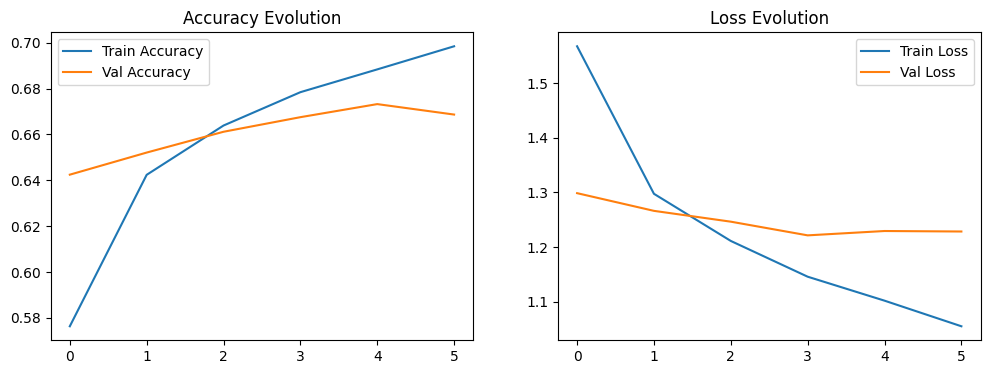

In [41]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 4))

# Plot Accuracy
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Val Accuracy')
plt.title('Accuracy Evolution')
plt.legend()

# Plot Loss
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('Loss Evolution')
plt.legend()

plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 4s 4s/step


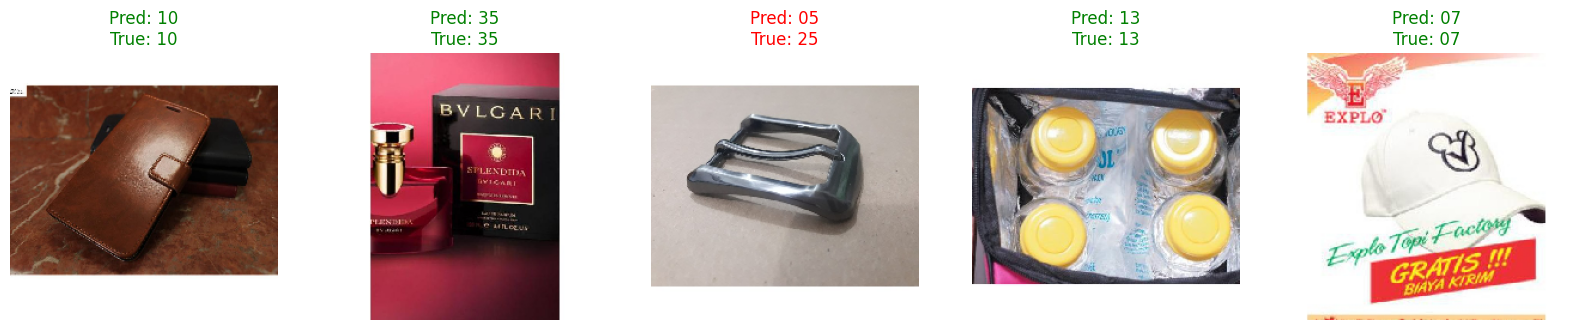

In [47]:

x_test, y_test = next(val_generator)
predictions = model.predict(x_test)

labels = (train_generator.class_indices)
labels = dict((v,k) for k,v in labels.items())


plt.figure(figsize=(20, 10))
for i in range(5):
    plt.subplot(1, 5, i+1)
    plt.imshow(x_test[i])

    pred_label = labels[np.argmax(predictions[i])]
    true_label = labels[np.argmax(y_test[i])]

    color = 'green' if pred_label == true_label else 'red'
    plt.title(f"Pred: {pred_label}\nTrue: {true_label}", color=color)
    plt.axis('off')

plt.show()

--- TOP 5 LARGEST CATEGORIES ---
category
0    2683
1    2702
2    2687
3    2703
4    2703
Name: count, dtype: int64

--- BOTTOM 5 SMALLEST CATEGORIES ---
category
37    1725
38    2673
39    2678
40    2681
41    2662
Name: count, dtype: int64


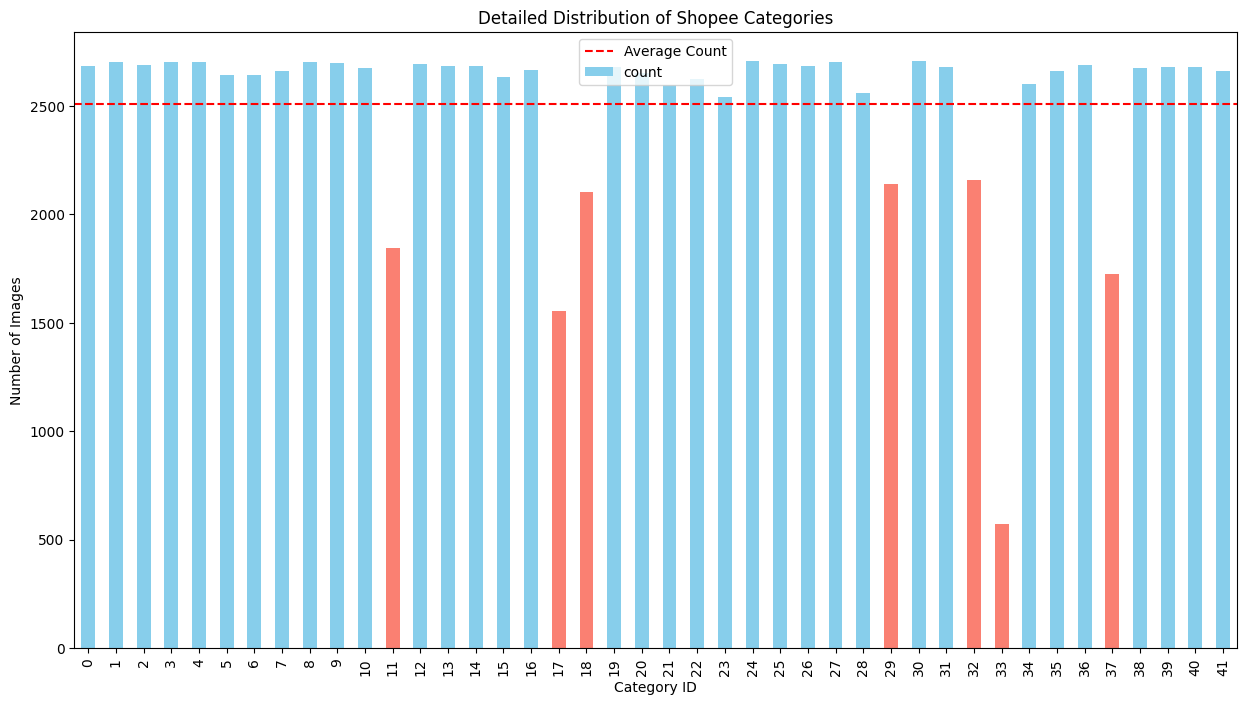

In [27]:
# 1. Get the counts
category_counts = train_df['category'].value_counts().sort_index()

# 2. Print a nice summary
print("--- TOP 5 LARGEST CATEGORIES ---")
print(category_counts.head(5))

print("\n--- BOTTOM 5 SMALLEST CATEGORIES ---")
print(category_counts.tail(5))

# 3. Enhanced Visualization
plt.figure(figsize=(15, 8))
colors = ['skyblue' if count > category_counts.mean() else 'salmon' for count in category_counts]
category_counts.plot(kind='bar', color=colors)

plt.axhline(y=category_counts.mean(), color='red', linestyle='--', label='Average Count')
plt.title("Detailed Distribution of Shopee Categories")
plt.xlabel("Category ID")
plt.ylabel("Number of Images")
plt.legend()
plt.show()

In [28]:
model.save('jiya_shopee_classifier_final.keras')

In [29]:
# Unfreeze the MobileNetV2 base
base_model.trainable = True

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5), # 0.00001
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [30]:
from sklearn.utils import class_weight

weights = class_weight.compute_class_weight(
    'balanced',
    classes=np.unique(train_df['category']),
    y=train_df['category']
)
class_weights = dict(enumerate(weights))
\
history_finetune = model.fit(
    train_generator,
    epochs=5,
    validation_data=val_generator,
    class_weight=class_weights
)

Epoch 1/5
2636/2636 ━━━━━━━━━━━━━━━━━━━━ 641s 220ms/step - accuracy: 0.6173 - loss: 1.3761 - val_accuracy: 0.6790 - val_loss: 1.1886
Epoch 2/5
2636/2636 ━━━━━━━━━━━━━━━━━━━━ 529s 201ms/step - accuracy: 0.6813 - loss: 1.1218 - val_accuracy: 0.6988 - val_loss: 1.1152
Epoch 3/5
2636/2636 ━━━━━━━━━━━━━━━━━━━━ 525s 199ms/step - accuracy: 0.7092 - loss: 1.0160 - val_accuracy: 0.7108 - val_loss: 1.0731
Epoch 4/5
2636/2636 ━━━━━━━━━━━━━━━━━━━━ 533s 202ms/step - accuracy: 0.7264 - loss: 0.9407 - val_accuracy: 0.7174 - val_loss: 1.0500
Epoch 5/5
2636/2636 ━━━━━━━━━━━━━━━━━━━━ 543s 206ms/step - accuracy: 0.7433 - loss: 0.8790 - val_accuracy: 0.7244 - val_loss: 1.0345


In [31]:
model.save('jiya_shopee_final_v2.keras')
print("Model saved successfully!")

Model saved successfully!


In [45]:
from tensorflow.keras.models import load_model
model = load_model('jiya_shopee_final_v2.keras')

model.summary() # Verify it's the right one

✅ Model reverted to the saved version!


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 42)             │         5,418 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 7,213,888 (27.52 MB)

 Trainable params: 2,393,258 (9.13 MB)

 Non-trainable params: 34,112 (133.25 KB)

 Optimizer params: 4,786,518 (18.26 MB)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step


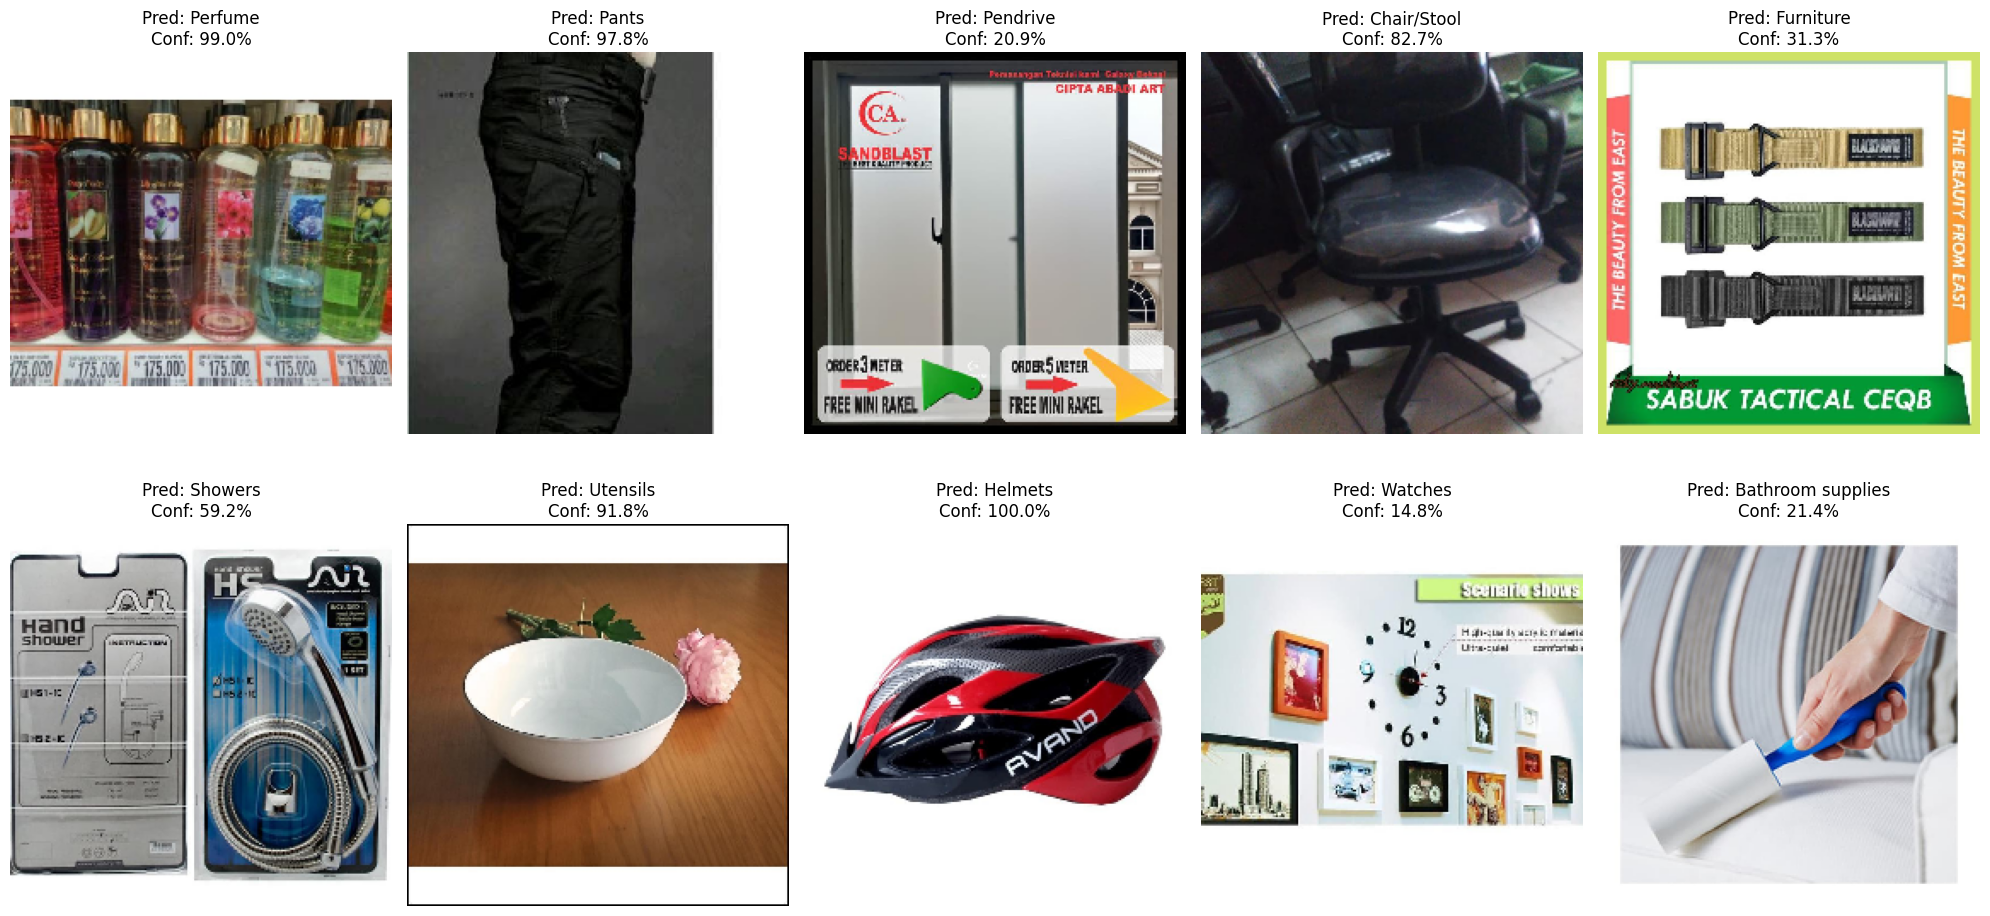

In [48]:
import random
from tensorflow.keras.preprocessing import image

test_dir = r"/root/.cache/kagglehub/datasets/kennethrithvik/shopee/versions/3/test/test"

test_images = [f for f in os.listdir(test_dir) if f.endswith(('.jpg', '.png', '.jpeg'))]

random_samples = random.sample(test_images, 10)

labels_map = {v: k for k, v in train_generator.class_indices.items()}
category_names = {
    "00": "Dresses",
    "01": "Long Dresses",
    "02":"Summer Clothes",
    "03":"Winter Clothes",
    "04":"Jeans",
    "05":"Rings",
    "06":"Earrings",
    "07":"Headwear",
    "08":"Purses",
    "09":"Handbags",
    "10":"Mobile Covers",
    "11":"Mobile Phones",
    "12":"Watches",
    "13":"Baby Sippers",
    "14":"Cookers",
    "15":"Coffees",
    "16":"Shoes/Slippers",
    "17":"Heels",
    "18":"Refridgerators",
    "19": "Pendrive",
    "20":"Chair/Stool",
    "21":"Racket",
    "22":"Helmets",
    "23":"Gloves",
    "24":"Wrist Watches",
    "25":"Belts",
    "26":"Earphones/HeadPhones",
    "27":"Toys",
    "28":"Jacket",
    "29":"Pants",
    "30":"Shoes",
    "31":"Snack",
    "32":"Masks",
    "33":"Sanitizers",
    "34":"Skin Products",
    "35":"Perfume",
    "36":"Bathroom supplies",
    "37":"Laptop",
    "38":"Utensils",
    "39":"Home Decor",
    "40":"Showers",
    "41":"Furniture"
}

plt.figure(figsize=(20, 10)) # Adjust figure size for 10 images
for i, img_name in enumerate(random_samples):
    img_path = os.path.join(test_dir, img_name)

    img = image.load_img(img_path, target_size=(224, 224))
    img_array = image.img_to_array(img) / 255.0
    img_array = np.expand_dims(img_array, axis=0)

    # Get predictions for the current image
    predictions = model.predict(img_array)
    pred_idx = np.argmax(predictions[0])
    confidence = np.max(predictions[0]) * 100

    pred_id = labels_map[pred_idx]
    pred_name = category_names.get(pred_id, f"ID: {pred_id}") # Fallback to ID if name unknown

    # Display
    plt.subplot(2, 5, i + 1) # 2 rows, 5 columns for 10 images
    plt.imshow(img) # Display original image for better visuals
    plt.title(f"Pred: {pred_name}\nConf: {confidence:.1f}%")
    plt.axis('off')

plt.tight_layout()
plt.show()

In [50]:
val_generator.reset()

val_generator.shuffle = False

y_pred = model.predict(val_generator)
y_pred_classes = np.argmax(y_pred, axis=1)

y_true = val_generator.classes

from sklearn.metrics import classification_report
report = classification_report(y_true, y_pred_classes, target_names=list(train_generator.class_indices.keys()))
print(report)

659/659 ━━━━━━━━━━━━━━━━━━━━ 84s 128ms/step
              precision    recall  f1-score   support

          00       0.55      0.51      0.53       536
          01       0.69      0.71      0.70       540
          02       0.62      0.62      0.62       537
          03       0.62      0.64      0.63       540
          04       0.90      0.90      0.90       540
          05       0.70      0.69      0.70       528
          06       0.70      0.83      0.76       528
          07       0.83      0.82      0.82       532
          08       0.73      0.75      0.74       540
          09       0.71      0.70      0.71       539
          10       0.77      0.78      0.77       534
          11       0.78      0.83      0.80       368
          12       0.82      0.77      0.79       538
          13       0.77      0.78      0.78       536
          14       0.86      0.76      0.81       536
          15       0.70      0.72      0.71       526
          16       0.75      0.69    